# Final Project

This notebook is adapted from here: https://aiqm.github.io/torchani/examples/nnp_training.html

## Checkpoint 1: Data preparation

1. Create a working directory: `/global/scratch/users/[USER_NAME]/[DIR_NAME]`. Replace the [USER_NAME] with yours and specify a [DIR_NAME] you like.
2. Copy the Jupyter Notebook to the working directory
3. Download the ANI dataset `ani_dataset_gdb_s01_to_s04.h5` from bCourses and upload it to the working directory

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torchani

### Use GPU

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


### Set up AEV computer

#### AEV: Atomic Environment Vector (atomic features)

Ref: Chem. Sci., 2017, 8, 3192

In [3]:
def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)


    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    aev_computer = torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )
    return aev_computer

aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(aev_dim)

384


### Prepare dataset & split

In [4]:
def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset

dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
# Use dataset.split method to do split
train_data, val_data, test_data = dataset.split(0.8, 0.1, None)

### Batching

In [5]:
batch_size = 8192
# use dataset.collate(...).cache() method to do batching
train_data_loader = train_data.collate(batch_size).cache()
val_data_loader = val_data.collate(batch_size).cache()
test_data_loader = test_data.collate(batch_size).cache()

### Torchani API

In [10]:
class AtomicNet(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.layers(x)

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [11]:
train_data_batch = next(iter(train_data_loader))

loss_func = nn.MSELoss()
species = train_data_batch['species'].to(device)
coords = train_data_batch['coordinates'].to(device)
true_energies = train_data_batch['energies'].to(device).float()
_, pred_energies = model((species, coords))
loss = loss_func(true_energies, pred_energies)
print(loss)

tensor(0.0593, grad_fn=<MseLossBackward0>)


## Checkpoint 2 : Network construction and workflow development ##

In [12]:
import matplotlib.pyplot as plt

In [13]:
class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model
        
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        
        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(model.parameters(), learning_rate, weight_decay=l2)
        self.epoch = epoch
    
    def train(self, train_data, val_data, early_stop=True, draw_curve=True, max_train_batches=None, max_val_batches=None):
        self.model.train()
        
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(self.batch_size).cache()
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        
        for i in tqdm(range(self.epoch), leave=True):
            self.model.train()
            train_epoch_loss = 0.0
            total_samples = 0
            
            for batch_idx, train_data_batch in enumerate(train_data_loader):
                if max_train_batches is not None and batch_idx >= max_train_batches:
                    break
                
                # compute energies
                species = train_data_batch['species'].to(device)
                coords = train_data_batch['coordinates'].to(device)
                true_energies = train_data_batch['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)
                
                # do a step
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()

                batch_importance = species.shape[0]
                train_epoch_loss += batch_loss.item() * batch_importance
                total_samples += batch_importance

            train_epoch_loss /= total_samples
            
            # use the self.evaluate to get loss on the validation set 
            val_epoch_loss = self.evaluate(val_data, draw_plot=False, max_batches=max_val_batches)
            
            # append the losses
            train_loss_list.append(train_epoch_loss)
            val_loss_list.append(val_epoch_loss)

            print(f"Epoch {i+1}/{self.epoch} | Train Loss: {train_epoch_loss:.6f} | Val Loss: {val_epoch_loss:.6f}")
            
            if early_stop:
                if val_epoch_loss < lowest_val_loss:
                    lowest_val_loss = val_epoch_loss
                    weights = self.model.state_dict()
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            # Plot train loss and validation loss
            ax.plot(range(1, len(train_loss_list) + 1), train_loss_list, label='Train')
            ax.plot(range(1, len(val_loss_list) + 1), val_loss_list, label='Validation')
            ax.legend()
            ax.set_xlabel("# Batch")
            ax.set_ylabel("Loss")
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False, max_batches=None):
        
        # init data loader
        data_loader = data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        total_samples = 0
        
        if draw_plot:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for batch_idx, batch_data in enumerate(data_loader):
                if max_batches is not None and batch_idx >= max_batches:
                    break
                
                # compute energies
                species = batch_data['species'].to(device)
                coords = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)

                batch_importance = species.shape[0]
                total_loss += batch_loss.item() * batch_importance
                total_samples += batch_importance
                
                if draw_plot:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())
                    
        total_loss /= total_samples

        if draw_plot:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777
            mae = np.mean(np.abs(true_energies_all - pred_energies_all)) * hartree2kcalmol
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()
            
        return total_loss

### Train a small subset of the data: ###

In [12]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

Sequential - Number of parameters: 197636
Initialize training data...


 33%|███▎      | 1/3 [00:24<00:48, 24.32s/it]

Epoch 1/3 | Train Loss: 0.014665 | Val Loss: 0.013151


 67%|██████▋   | 2/3 [00:26<00:11, 11.44s/it]

Epoch 2/3 | Train Loss: 0.010882 | Val Loss: 0.010076


100%|██████████| 3/3 [00:30<00:00, 10.03s/it]

Epoch 3/3 | Train Loss: 0.008640 | Val Loss: 0.008183


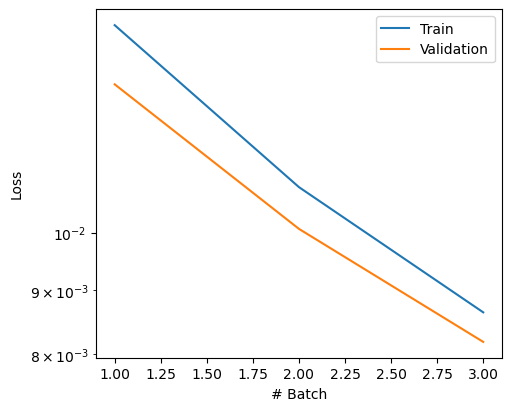

In [13]:
trainer = ANITrainer(
    model,
    batch_size=128,
    learning_rate=1e-3,
    epoch=3,
    l2=1e-5
)

train_loss_list, val_loss_list = trainer.train(
    train_data,
    val_data,
    early_stop=True,
    draw_curve=True,
    max_train_batches=5,
    max_val_batches=2
)

0.008182576857507229

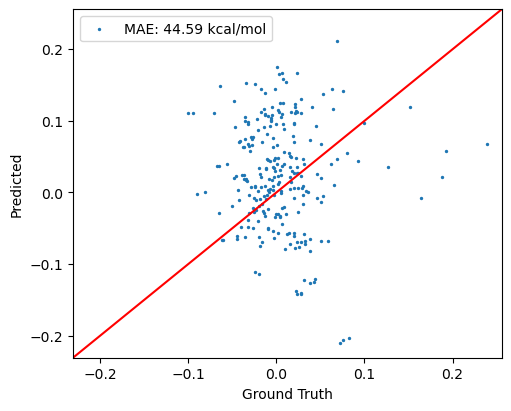

In [14]:
trainer.evaluate(val_data, draw_plot=True, max_batches=2)

The ANI model was trained using MSE loss (for solving regression problems) and Adam optimizer (because it works more efficiently, the tutorial also used Adam as the default optimizer). 

Both training and validation losses decrease over epochs, indicating that the model is learning.

The evaluation shows a relatively high MAE(Mean Absolute Error more sutable for evaluation), which is expected due to training on a small subset with small amount of epochs. 

So, overall, the training and evaluation pipeline works correctly.